# Minimal inference example — aurora-latent-to-sm (unet)

A self-contained example: **load a trained checkpoint → run a short roll-out →
plot the predicted surface soil moisture**. Uses only `matplotlib` and this
repo's `train_hydr` package (no external plotting libraries).

**Requirements**
- A trained checkpoint (`paths.experiment_root` in `train_hydr/config.yaml`).
- ERA5 inputs + the static file (paths also in `train_hydr/config.yaml`).
- Run this notebook from `models/unet/` so that `train_hydr` is importable.


## 0. Setup

In [1]:
import os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

# Run from models/unet/ so the local `train_hydr` package is importable.
sys.path.append(os.getcwd())

from train_hydr import rollout, load_model, load_nc_list, load_data
from train_hydr import AuroraDatasetLiteDecoder
from aurora.batch import _np

# --- settings (edit to your setup) ---
device         = "cuda:0"              # or "cpu"
exp_name       = "unet"
model_key      = "load_aurora_lite_model"
suffix         = "0107_0803_10years"   # your training-run folder name
checkpoint_num = 10
start_date, end_date = "2015-04-01", "2015-04-05"
n_steps        = 8                     # short roll-out (8 x 6h = 2 days)

cfg = OmegaConf.load("train_hydr/config.yaml")   # all data/checkpoint paths live here


/opt/conda/envs/aurora/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load one input sample
ERA5 inputs and the static file are read from the paths in `config.yaml`.

In [2]:
surf, atmo, hydr, et, stat_ds = load_nc_list(
    cfg.paths.base_era5, static_path=cfg.paths.static_file,
    start_date=start_date, end_date=end_date,
    output_list=("surf", "atmo", "hydr", "et", "stat"),
)
(p_paths,) = load_nc_list(
    cfg.paths.base_mswep, start_date=start_date, end_date=end_date, output_list=("p",),
)
_, dataset = load_data(surf, atmo, hydr, et, p_paths, stat_ds, train_test_ratio=0)

lsm_mask = stat_ds["lsm"].values.squeeze()[:720, :1440] >= 0.5   # land/sea mask
lat = stat_ds["latitude"].values[:720]
lon = stat_ds["longitude"].values[:1440]
print("available samples:", len(dataset))


available samples: 18


## 2. Load the trained model

In [3]:
ckpt_path = f"{cfg.paths.experiment_root}{exp_name}/{suffix}/checkpoint_epoch_{checkpoint_num:03d}.pth"
checkpoint = torch.load(ckpt_path, map_location="cpu")

modelAurora, modelDecoder = load_model(model_key)
modelDecoder.load_state_dict(checkpoint["model_state_dict"])
modelAurora = modelAurora.to(device).eval()
modelDecoder = modelDecoder.to(device).eval()
print("checkpoint loaded:", ckpt_path)


checkpoint loaded: /home/jovyan/data1/pvc-ab429081-d17e-4c2b-8f4e-bf1bc772ea50/aurora_experiments/unet/0107_0803_10years/checkpoint_epoch_010.pth


## 3. Run a short roll-out
Collect the predicted `swvl1` (surface soil moisture) map at each lead step.

In [4]:
idx = 1                                   # starting sample
(batch_obj, input_dict), _ = dataset[idx]

swvl1_steps = []
with torch.inference_mode():
    for pred_Aurora, pred_Decoder in rollout(
        modelAurora, modelDecoder, batch_obj, input_dict, steps=n_steps
    ):
        data = _np(pred_Decoder["swvl1"][0]).copy()   # (B,T,H,W) -> (T,H,W)
        data = np.where(data >= 0, data, 0)           # clip negatives
        data = np.where(lsm_mask, data, np.nan)       # mask ocean
        swvl1_steps.append(data[0])                   # (H, W) for this lead step

print("collected", len(swvl1_steps), "lead-time maps")


collected 8 lead-time maps


## 4. Visualize (matplotlib only)

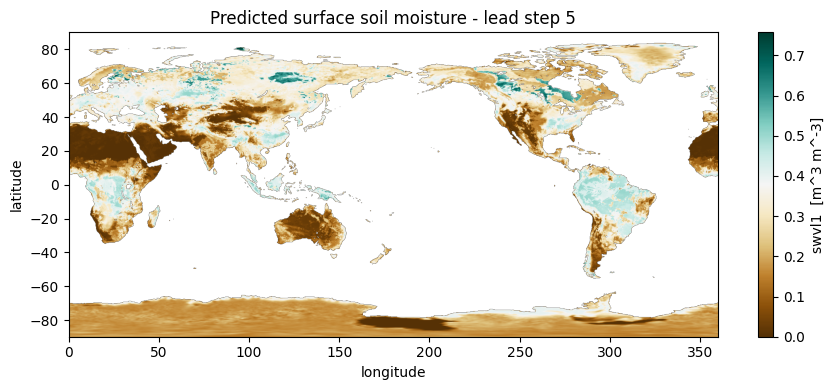

In [6]:
lead = min(4, len(swvl1_steps) - 1)       # pick a lead-time index

plt.figure(figsize=(9, 4))
plt.imshow(
    swvl1_steps[lead], origin="upper", cmap="BrBG",
    extent=[lon.min(), lon.max(), lat.min(), lat.max()], aspect="auto",
)
plt.colorbar(label="swvl1  [m^3 m^-3]")
plt.title(f"Predicted surface soil moisture - lead step {lead + 1}")
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.tight_layout(); plt.show()
